## Healthy Blood Prediction

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

This dataset was collected to help predict from a blood exam if a patient is healthy or has hepatitis C ([source](https://archive.ics.uci.edu/ml/datasets/HCV+data)). It contains the laboratory results from the blood examinations of patients and their diagnosis.

While diagnostic pathways are based on expert rules (if-then-else rules), machine learning algorithms can go beyond these methods, and learn predictions rules directly from the data.

Our goal in this exercise is to implement a logistic regression model for prediction and understand some of its properties. In the second part of this exercise you will implement all methods by yourself, **without using the sklearn library**.

For reference, you find the `sklearn` Logistic Regression at [sklearn-logreg](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

## Preparing the dataset

First, load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('data/blood.csv')
df.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


The 'Category' column indicates the health status of the patient. 

In [3]:
df["Category"].value_counts()

Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

#### 1. Create target variable

Create a binary variable called `healthy` that is one when the patient is a healthy (category `'0=Blood Donor'`), and zero otherwise. Inspect how many samples are healthy and how many are not, using the `value_counts()` method. 

Calculate the percentage of healthy patient in the dataset, and save it to the variable `perc_healthy`.

In [4]:
# Add your code below
df['healthy'] = df['Category'].apply(lambda x: 1 if x == '0=Blood Donor' else 0)

perc_healthy = df['healthy'].mean() * 100
print(f"{perc_healthy:.2f}%")

86.67%


Once you have calculated `perc_healthy`, uncomment the cell below and print it out:

In [5]:
perc_healthy

np.float64(86.66666666666667)

Note that the dataset is imbalanced, with much higher proportion of healthy samples. This imbalance makes the task harders, as there is a small number of samples from the unhealthy class to learn from.

#### Inspect the columns of the model with the 'info' method. 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  615 non-null    str    
 1   Age       615 non-null    int64  
 2   Sex       615 non-null    str    
 3   ALB       614 non-null    float64
 4   ALP       597 non-null    float64
 5   ALT       614 non-null    float64
 6   AST       615 non-null    float64
 7   BIL       615 non-null    float64
 8   CHE       615 non-null    float64
 9   CHOL      605 non-null    float64
 10  CREA      615 non-null    float64
 11  GGT       615 non-null    float64
 12  PROT      614 non-null    float64
 13  healthy   615 non-null    int64  
dtypes: float64(10), int64(2), str(2)
memory usage: 67.4 KB


#### 2. Clean the dataset 

Notice in `.info()` that the Non-Null values indicate that the dataset has missing values. Print the number of missing values for each column.

In [7]:
df.isnull().sum()

Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
healthy      0
dtype: int64


We must make a decision about how to correct them. Possible solutions are imputation, deletion of the problematic variables (columns) or deletion of problematic samples (rows). As there is a small number of samples with missing values (and for the sake of time), we will drop them. 

Create a clean dataframe by removing samples that have non-valid values, and save it to `df_clean`. 

Turn the categorical variable `Sex` to a valid input representation. Use a binary representation: `True` if equal to `m`, `False` otherwise.

And drop any columns that won't be used in the prediction model. Use `.info()` again to check the new dataset is clean.

*Hint: use the `dropna()` and `drop` methods.*

In [8]:
# Add your code below
df_clean = df.dropna().copy()
df_clean['Sex'] = df_clean['Sex'] == 'm'

to_drop = ['Category']
df_clean = df_clean.drop(columns=to_drop)

Once you have calculated `df_clean`, uncomment and run the cell below:

In [9]:
df_clean.head(3)

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,healthy
0,32,True,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,1
1,32,True,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,1
2,32,True,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,1


## Single variable model

We will start by analyzing a single variable column, which makes it easier to visualize the main principles of Logistic Regression. We choose the feature `AST` arbitrarily.

#### 3. Visualize how the target `healthy` depends on the variable `AST` with a scatter plot.

Use the `df.plot.scatter()` method and pass `ax=ax`, and `c=k` (color black).

Note that the `fig` and `ax` variables can be reused in cells below to plot over this figure.

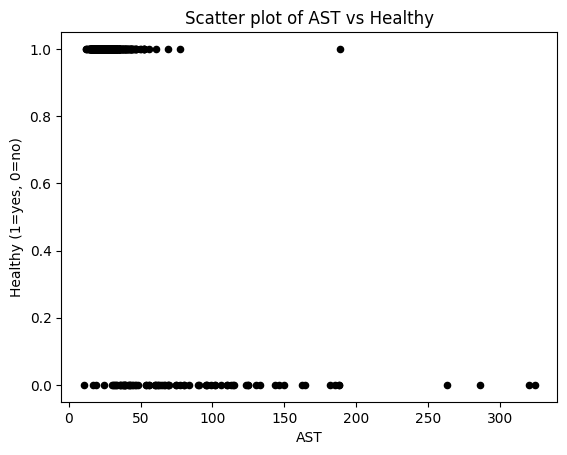

In [10]:
fig,ax = plt.subplots()
# Add your code below
df.plot.scatter(x='AST', y='healthy',ax=ax,c='black')
ax.set_xlabel('AST')
ax.set_ylabel('Healthy (1=yes, 0=no)')
ax.set_title('Scatter plot of AST vs Healthy')
plt.show()

#### 4. Implement a function that creates and fits a logistic regression model given the input and output data. 

In [11]:
# Add your code below
def logreg(X,Y):
    model = LogisticRegression()
    model.fit(X,Y)
    return model

#### 5. Fit a model named `model_AST` that predict the status `healthy` from the variable `AST`. 

Note: for the test on KATE to pass, use the dataframe `df` (and not `df_clean`) to define the input features `X` and the labels `y` to train your model `model_AST`.

In [12]:
# Add your code below
X = df[['AST']]
y = df['healthy']
model_AST = logreg(X,y)

#### 6. Calculate the prediction probability for each data point. 

Using `model_AST`, calculate the prediction probabilities for all data points, saved as `y_prob`. 

Plot the result using `ax.scatter()`, which will reuse the plot created above, and the command `fig` will plot the resulting figure here. Use the color blue for this new plot, using the argument `color='tab:blue'`. 

Note: the `tab` colors are the new standard matplotlib colors (the "Tableau Palette").

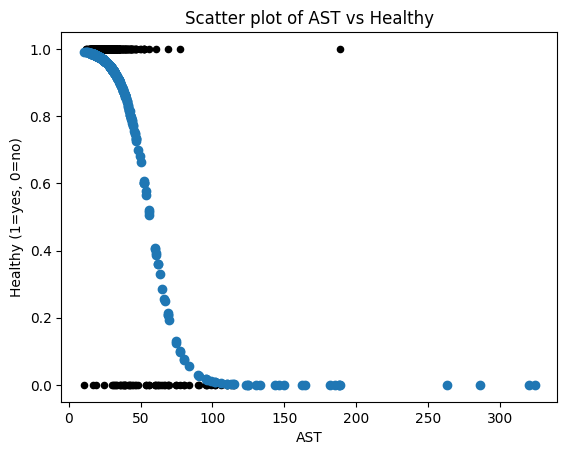

In [13]:
# Add your code below
y_prob = model_AST.predict_proba(X)[:,1]
ax.scatter(X, y_prob, color='tab:blue')
fig

#### 7. Calculate the deterministic predictions. 

Calculate the deterministic predictions, deciding that it is healthy if the output probability is larger than 50%, in a variable `y_pred`. 

Plot the predictions for each data point, again superimposed on the results above using `ax.scatter()`. Use small red markers, using the arguments `c=tab:red` and `marker='.'`.

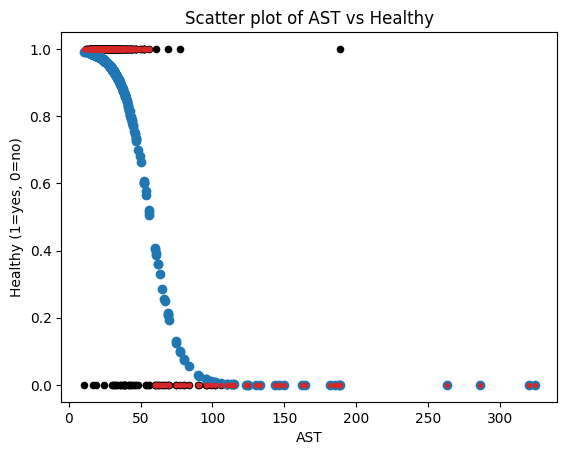

In [14]:
# Add your code below
y_pred = (y_prob > 0.5).astype(int)
ax.scatter(
    X["AST"],
    y_pred,
    c="tab:red",
    marker="."
)
fig

#### 8. Notice that your model is deciding a sample is healthy if `ALS` is below a certain threhold. Calculate this threshold from the bias and weight parameters of the model. 
 
Draw the threshold as a vertical line, superimposed on the plots above using `ax.plot()`, and again in the color red. 

Note that this line represents a decision boundary: the model's decision is based on which side of it a sample lies.

*Hint: use the `model.intercept_` and `model.coef_` attributes as bias and weight attributes respectively, and that at the decision bourdary we have $w x - b = 0$, where $w$ is the weight and $b$ the bias.*

*Hint: to draw a vertical line at some value, `x`, use `ax.plot([x,x], [0,1])`.*

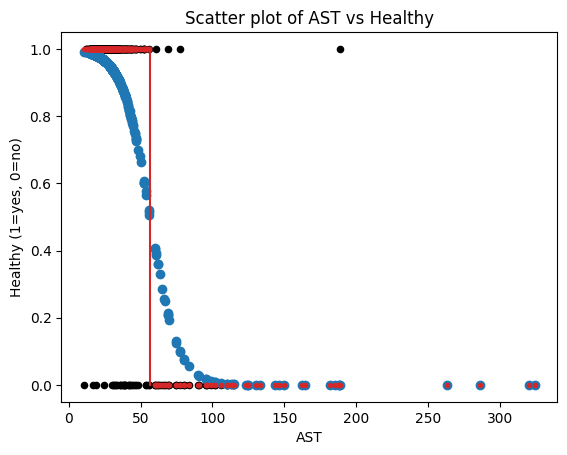

In [15]:
# Add your code below
ALS_thres = -model_AST.intercept_[0] / model_AST.coef_[0][0]
ax.plot([ALS_thres, ALS_thres], [0, 1], color='tab:red')  
fig

#### 9. Calculate and plot the ROC curve for the predictions. 

ROC Curves summarise the trade-off between the true positive rate and false positive rate for a predictive model using different probability thresholds.

ROC curves are appropriate when the observations are balanced between each class, whereas precision-recall curves are appropriate for imbalanced datasets.

Use the new axis for the plot, using `ax_roc.plot()`. Limit the plot range to valid values, between zero and one.

(0.0, 1.0)

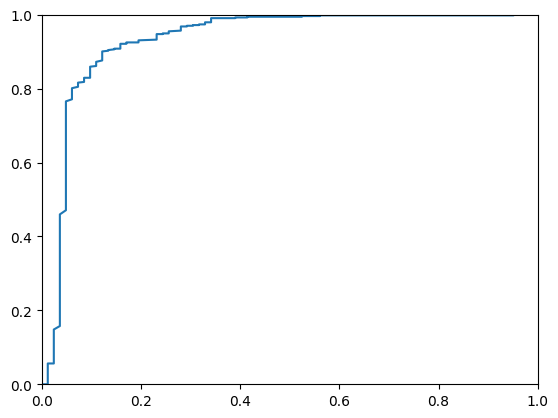

In [16]:
from sklearn.metrics import roc_curve
fig_roc, ax_roc = plt.subplots()
# Add your code below
y_original = df['healthy']  
fpr, tpr, thresholds = roc_curve(y_original, y_prob)
ax_roc.plot(fpr, tpr)
ax_roc.set_xlim([0, 1])                                                  
ax_roc.set_ylim([0, 1])                                                                                                                           

## Analysis of multivariate logistic regression model

#### Now, we will use all the input variables.

Let's start by uncommenting the cell below and inspecting the first 3 lines of our `df_clean` DataFrame.

In [17]:
df_clean.head(3)

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,healthy
0,32,True,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,1
1,32,True,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,1
2,32,True,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,1


#### 10. Create a logistic regression model using all input columns from the clean data frame. 

#### Optimization algorithms can perform better with normalized input variables. To normalize the input features of your model (`X`), create a new variable called `X_norm` and use `X_norm` when training your model called `full_model`.

*Hint:  Use the z-score transformation $$\frac{x - \mu}{\sigma}$$ with the  `mean()` and `std()` methods.*

In [18]:
# Add your code below
X = df_clean.drop(columns=['healthy'])
y = df_clean['healthy']                                                
X_norm = (X - X.mean()) / X.std()                                        
full_model = logreg(X_norm, y)

#### 11. Calculate the prediction probabilities. 

#### Plot the histograms of the prediction probabilities, separately for healthy cases and for unhealthy cases. Do you think the model is any good?

Set the numbers of bins to 30 (`bins=30`), use the `step` histogram type (`histtype='step'`), and set the density mode to on (`density=True`).

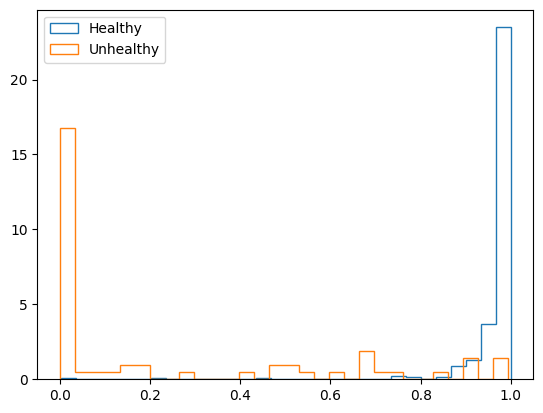

In [19]:
# Add your code below 
fig_hist, ax_hist = plt.subplots()
y_prob_full = full_model.predict_proba(X_norm)[:, 1]        
y_clean = df_clean['healthy']                                            
ax_hist.hist(y_prob_full[y_clean == 1], bins=30, histtype='step',        
density=True, label='Healthy')                                           
ax_hist.hist(y_prob_full[y_clean == 0], bins=30, histtype='step',        
density=True, label='Unhealthy')    
ax_hist.legend()

#### The ROC curve indicate the false positive and negative error rates for different choices of decision thresholds, varying from zero to one.

#### 12. Calculate the ROC for the full model.

#### Superimpose the result over the ROC for the `ALS` model, reusing the `ax_roc` axis above. 

####  Which model has better predictions?

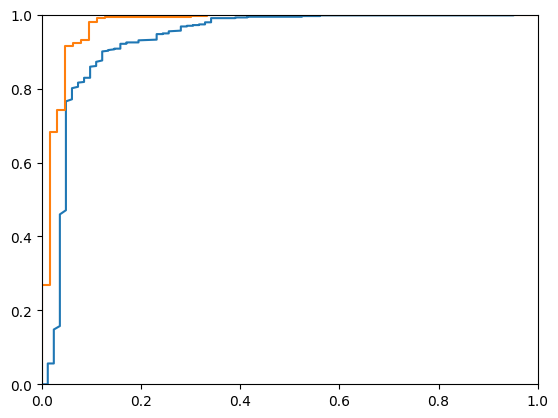

In [20]:
# Add your code below
y_clean = df_clean['healthy']  
fpr_full, tpr_full, thresholds_full = roc_curve(y_clean, y_prob_full)          
ax_roc.plot(fpr_full, tpr_full, label='Full model')                      
fig_roc

#### 13.By using a confusion matrix for the predictions with a 50% threshold, calculate the false positive rate and false negative rate.

You can review the elements of a confusion matrix in [link](https://www.nbshare.io/notebook/626706996/Learn-And-Code-Confusion-Matrix-With-Python/). 

The false positive rate is given by: (false positives)/(all actual negatives) 
The false negative rate is: (false negatives)/(all actual positives)

#### Notice that false positives and false negatives have very different probabilities. Think about why this is the case.
*Hint: Remember the imbalance in number of healthy and unhealthy samples.*

In [22]:
from sklearn.metrics import confusion_matrix
# Add your code below
y_pred_full = (y_prob_full > 0.5).astype(int)
CM = confusion_matrix(y_clean, y_pred_full)
tn, fp, fn, tp = CM.ravel()
                                                                           
false_pos = fp / (fp + tn)
false_neg = fn / (fn + tp)

Once you have implemented the confusion matrix and the error probabilities for healthy and unhealthy cases, uncomment and run the cell below to inspect these values:

In [23]:
print(CM)
print(false_neg)
print(false_pos)

[[ 46  17]
 [  3 523]]
0.005703422053231939
0.2698412698412698


#### 14. Calculate and print the decision probability threshold that would give same error probability for false positives and false negatives. 

*Hint: Find where in ROC curve false negatives become larger than false positives, using the `np.where()` function. Then use the third element of the ROC output (`ROC2[2]`), which tells the probability threshold at that point of the ROC curve.*

In [28]:
# Add your code below
ROC = roc_curve(y_clean, y_prob_full)                                                    
fpr_full, tpr_full, thresholds_full = ROC

fnr = 1 - tpr_full  
idx = np.where(fnr > fpr_full)[0] 
index_roc = idx[idx > 0][0]                      # skip first threshold / index 0 has inf threshold                                 
decision_thres = thresholds_full[index_roc]

When you have calculated `decision_thres`, uncomment the cell below to print it out:

In [25]:
decision_thres

np.float64(inf)

#### 15. Mark over the ROC curve the point corresponding to the balanced error choice above.

#### Use `ax_roc.plot()` to plot over the ROC figure above. Plot a single marker by plotting the x and y values of the ROC curve in `ROC2` for the correct index. Use the plotting argument `gx` for a green X marker.

#### Also, calculate the ROC point for the 50% decision threshold considered above. Mark it as a red X marker in the same figure.

#### Which decision threshold is preferable? What would this preference depend on?

*Hint: Think about what is worse, false positive or false negatives?*

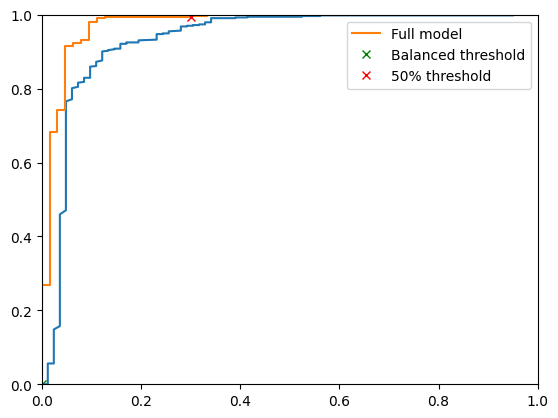

In [29]:
# Add your code below
ROC_index = np.where(thresholds_full <= 0.5)[0][0]
                                                                                           
ax_roc.plot(fpr_full[index_roc], tpr_full[index_roc], 'gx', label='Balanced threshold')  
ax_roc.plot(fpr_full[ROC_index], tpr_full[ROC_index], 'rx', label='50% threshold')
ax_roc.legend()                                                                          
fig_roc          

## Implementing the model from scratch

Most machine learning models are trained with gradient descent, updating model parameters with small changes in the direction that reduces the training loss. 

#### To learn in detail what goes on when we use libraries to train our model,  we will now implement the gradient descent algorithm from scratch and compare the results with the scikit-learn package model. 

#### We give you here the gradient and loss functions for the logistic regression model.

In [30]:
sigma = lambda u: 1/(1+np.exp(-u))
def gradient(w,x,y):
    y_prob = sigma(x@w)
    return np.dot(x.T, (y_prob - y))/len(y)

def loss(w,x,y):
    y_prob = sigma(x@w)
    return -(y*np.log(y_prob)+(1-y)*np.log(1-y_prob)).mean()

#### 16. Implement a function that takes the input and output of the logistic regression model and fits it using gradient descent. 

Use random Gaussian initialization (with unit variance), no regularization, learning rate of 2., and 200 gradient descent steps. 

Also, calculate the total loss at each step. Return the final weight parameters and the total loss time series.

In [31]:
np.random.seed(0)
# Add your code below
def fit(X, y, lr=2., steps=200):                                                                                                                    
    # Gradient descent for logistic regression                                                                                                      
    np.random.seed(0)                                                                                                                               
    w = np.random.randn(X.shape[1])  # random Gaussian initialization                                                                               
    loss_t = []                                                                                                                                     
                                                                                                                                                      
    for t in range(steps):                                                                                                                          
        loss_t.append(loss(w, X, y))                                                                                                                
        w = w - lr * gradient(w, X, y)  # update weights in direction of steepest descent                                                           
                                                                                                                                                      
    return w, loss_t  

#### 17. Fit the model to our clean and normalized inputs. 

#### Calculate and print the final weights, named `w`, and plot the loss over time, named `loss_t`. 

#### Does it learn over time? Has it nearly converged?

Remember to add a constant column to the input for the bias parameter.

[ 3.59367522  0.09425416  0.30893019  1.01211581  1.42142925  0.49642705
 -2.33646261 -1.11616644 -0.42803688  0.70625341 -0.65606097 -1.88816686
 -0.17404143]


/var/folders/qx/l96sp59j46316s33f680yyr80000gp/T/ipykernel_22591/2350848300.py:8: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(y_prob)+(1-y)*np.log(1-y_prob)).mean()


Text(0.5, 1.0, 'Loss over time')

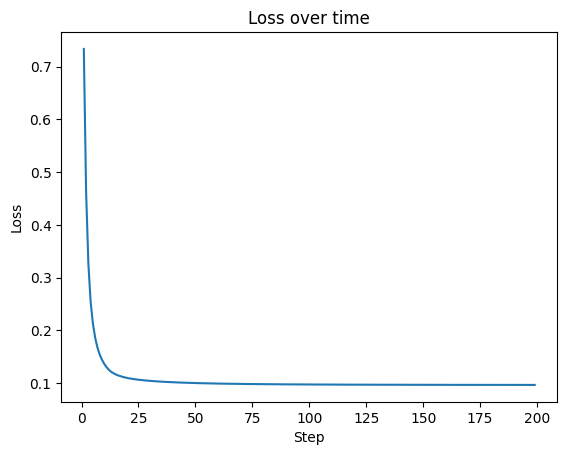

In [32]:
# Add your code below
X = np.column_stack([np.ones(len(X_norm)), X_norm.to_numpy()])  # add bias column                                                                   
Y = y_clean.to_numpy()                                                                                                                              
w, loss_t = fit(X, Y)                                                                                                                               
                                                                                                                                                      
print(w)                                                                                                                                        
plt.plot(loss_t)                                                                                                                                    
plt.xlabel('Step')                                                                                                                                  
plt.ylabel('Loss')                                                                                                                                  
plt.title('Loss over time')                                                                                                                                                

#### 18. Calculate and plot the probability predictions histograms for healthy and unhealthy samples. 

#### Use the same histogram properties as above

#### Has this model learned well?

*Hint: the output probability of the logistic regression model is $p(x=1) = \sigma(w^T x-b)$*.

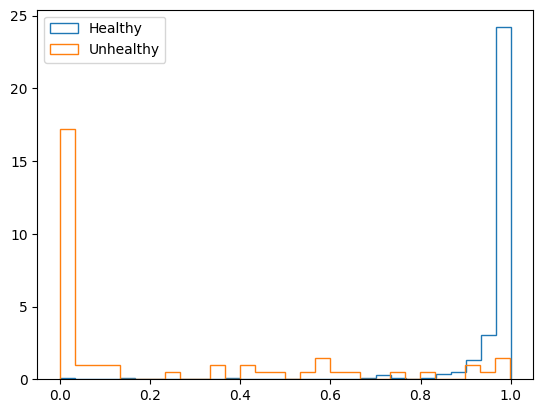

In [33]:
# Add your code below
y_prob3 = sigma(X @ w)                  
                                                                                                                                  
plt.figure()                                                                                                                                        
plt.hist(y_prob3[Y == 1], bins=30, histtype='step', density=True, label='Healthy')                                                                  
plt.hist(y_prob3[Y == 0], bins=30, histtype='step', density=True, label='Unhealthy')                                                                
plt.legend()                                                                                                                                        

#### 19. Compare the coefficients learned with our model and the scikit-learn model above. 

#### Make a scatter plot  using `plt.scatter`, with the vector of coefficients of each of the model as arguments. 

#### As a reference, plot a black dashed line on the main diagonal of the plot (i.e. where x=y). 

*Hint: Use `plt.plot([a,a],[b,b])` for some values `a` and `b`, and `k--` as argument.* 

#### Also, calculate and print the correlation between these two vectors, using the method `np.corrcoef()`, named `correlation`. 

#### Are the two models similar? Why should they be different, similar or identical?

Correlation: 0.9979


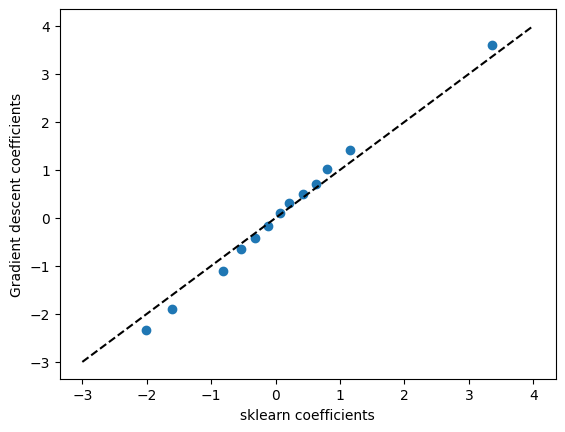

In [34]:
# Add your code below
# sklearn model coefficients (bias + features)
w_sklearn = np.concatenate([full_model.intercept_, full_model.coef_[0]])                                                                            
                                                                                                                                                      
plt.figure()                                                                                                                                        
plt.scatter(w_sklearn, w)                                                                                                                           
plt.plot([-3, 4], [-3, 4], 'k--')  # diagonal reference line                                                                                        
plt.xlabel('sklearn coefficients')                                                                                                                  
plt.ylabel('Gradient descent coefficients')                                                                                                         
                                                                                                                                                      
correlation = np.corrcoef(w_sklearn, w)[0, 1]                                                                                                       
print(f"Correlation: {correlation:.4f}")    